# `wcsb` — strat-column → GeoModel (Curlew / GeoINR integration, complex case)

Unit-only path of the GeoINR → Curlew integration with the **soft-unit / NLL coupling**
(SOFTUNIT_SPEC): the Western Canada Sedimentary Basin column (36 units,
conformal/baselap/eroded) observed as **unit points only** (`cleaner_markers.vtp`).
`build_geomodel` produces an **alternating chain** of erosional unconformities and
depositional packages with synthesized region-only events at both ends (Precambrian
basement at the bottom; the dropped top baselap unit at the top).

**Loss (joint soft-unit / NLL coupling):** all scalar fields plus shared, learnable
iso-values are coupled in one cross-entropy against the true unit levels. Each epoch the
field stack + iso-values are carved into an `(N, C)` per-class simplex (`soft_unit_probs`,
a per-class re-derivation of curlew's onlap/truncation combine) and trained with NLL — so
field values are calibrated everywhere and classification is globally consistent. A
**no-overturn** term keeps each field monotone upward; the per-field inequality loss is
off. Surfaces are **learned** (monotone-reparam iso-values), then written into ordinary
fixed isos by `write_isosurfaces` so `M.predict` reproduces the model.

This notebook is built for **inspection**: it renders the ordering structure and
per-field scalar fields (each field judged on its own), the combined model, per-point
accuracy, and the soft-carve↔predict consistency. Pipeline: **load → partition →
structure → joint fit → per-field fields → combined predict/3D → checks**.

## 0. Setup

In [1]:
%matplotlib inline
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import curlew
from curlew.io import loadObservations
from curlew.geology.stratbuilder import build_geomodel, attach_unit_loss
from curlew.geology.softunit import soft_unit_probs

DEVICE = os.environ.get("CURLEW_DEVICE", "cuda")
if DEVICE.startswith("cuda") and not torch.cuda.is_available():
    raise RuntimeError("CUDA requested but unavailable; set CURLEW_DEVICE=cpu to run on CPU.")
curlew.device = DEVICE
torch.manual_seed(0); np.random.seed(0)

CANDIDATES = [
    r"D:/Development/GeoINR_Research2/geoinr/data/wcsb",
    os.path.join(os.path.dirname(os.getcwd()), "data", "wcsb"),
    "./data/wcsb",
]
DATA = next((p for p in CANDIDATES if os.path.exists(os.path.join(p, "strat_col_v2.csv"))), None)
assert DATA is not None, f"Could not locate wcsb data; tried {CANDIDATES}"
STRAT_CSV = os.path.join(DATA, "strat_col_v2.csv")

# --- build knobs (reproducible) ---------------------------------------------
# FIELD: 'Siren' (omega 30) or 'GeoINR' (softplus MLP). Compare both.
FIELD = "Siren"
if FIELD == "Siren":
    FIELD_KWARGS = dict(omega0=30.0, omega=30.0, learning_rate=1e-4, hidden_dim=256)
else:  # softplus MLP — beta in ~[20, 50]
    FIELD_KWARGS = dict(activation=nn.Softplus(beta=40), learning_rate=1e-3, hidden_dim=256)
# cap per unit: on the COUPLED path balance comes from POINTS_PER_LEVEL (below), so the
# cap only limits the distinct geometry each field sees — keep it generous (a small cap
# starves the fields and hurts marker fit). Use None for the full point set if RAM allows.
CAP_PER_UNIT = 20000
IQ_SAMPLES   = 1024     # points drawn per inequality pool each step (used only to size pools)
N_EPOCHS     = 3000     # joint CE keeps improving with budget once the carve is well-posed

# --- soft-unit / NLL coupling knobs (SOFTUNIT_SPEC) -------------------------
# The coupled path replaces the per-field inequality fit + post-hoc surface estimation
# with ONE joint cross-entropy over all fields + learnable iso-values (§4). The carve
# (soft_unit_probs) is a per-class re-derivation of curlew's combine; classes are unit
# LEVELS (not lithoID). attach_unit_loss sets iq_norm_weight=0 (CE supersedes the
# inequalities) and RELAXES overturn (see below). Learnable iso-values init uniformly
# (correctness is owned by the monotone reparam + CE, so the init is just a convergence aid).
TAU              = 0.05     # soft-unit temperature; sharpness s = 1/tau = 20 (GeoINR)
POINTS_PER_LEVEL = 1024     # balanced points sampled per unit level each epoch

# no-overturn weight for the COUPLED path. The per-field path needs 30 (its sequential
# combine has no global ordering signal, so basement leaks through non-monotone deep fields
# — weight 1 → 66.5% inverted columns). But under the coupling the always-active CE already
# enforces ordering at every marker, so 30 is redundant AND over-smooths: it pins each field's
# range too small to separate a package's 7–9 bands (NLL stuck ~1.06). Relaxing to ~6 drops the
# NLL to ~0.8 (GeoINR's near-zero regularisation regime) and lifts marker accuracy, while
# keeping predicted column inversions low (~0.5%); lower (→1) fits a touch better but lets the
# deep unconstrained region overturn (several-% inversions). Passed to attach_unit_loss.
OVERTURN_WEIGHT = 6.0
print("device:", curlew.device, "| field:", FIELD, "| data:", DATA)

device: cuda | field: Siren | data: D:/Development/GeoINR_Research2/geoinr/data/wcsb


## 1. Load & normalize

Read the strat column and the **unit** observations. `build_geomodel` caps each unit
at `CAP_PER_UNIT` points, builds the event chain, and attaches an **anisotropic**
(`geo_extensive`) normalization `Transform` (the basin's xy extent is ~300× its thin
z, so z is vertically exaggerated into a comparable model range).

In [2]:
obs = loadObservations(units=os.path.join(DATA, "cleaner_markers.vtp"))
print("observations:", len(obs), "unit points |", obs.ndim, "D |",
      f"{len(obs.levels('unit'))} levels {obs.levels('unit')[0]}..{obs.levels('unit')[-1]}")

M = build_geomodel(STRAT_CSV, obs, field=FIELD, scale="geo_extensive",
                   cap_per_unit=CAP_PER_UNIT, iq_samples=IQ_SAMPLES, seed=0,
                   field_kwargs=FIELD_KWARGS)
T = M.normalization

observations: 4301145 unit points | 3 D | 36 levels 2..37


In [3]:
try:
    import pandas as pd
    display(pd.DataFrame([{"index": i, "name": u.name, "relation": u.relation, "level": u.level}
                          for i, u in enumerate(M.strat_units)]))
except Exception:
    for i, u in enumerate(M.strat_units):
        print(i, u.name, u.relation, u.level)

import itertools
lo, hi = obs.bounds(); lo = np.asarray(lo, float); hi = np.asarray(hi, float)
mc = T.apply(np.array(list(itertools.product(*zip(lo, hi))), dtype=float))
for ax, nm in enumerate("xyz"[:obs.ndim]):
    print(f"  {nm}: world extent {hi[ax]-lo[ax]:11.1f}  →  model [{mc[:,ax].min():6.3f}, {mc[:,ax].max():6.3f}]")

,index,name,relation,level
0,0,Quaternary - Late Cretaceous - Above Belly Riv...,baselap,2
1,1,Late Cretaceous - Belly River,eroded,3
2,2,Late Cretaceous - Milk River/ Medicine Hat,conformal,4
3,3,Late Cretaceous - Cardium,conformal,5
4,4,Late Cretaceous - 2nd White Specks / Dunvegan,baselap,6
5,5,Upper Early Cretaceous - Lower Colorado,eroded,7
6,6,Upper Early Cretaceous - Paddy / Viking / Bow ...,conformal,8
7,7,Upper Early Cretaceous - Upper Mannville,conformal,9
8,8,Upper Early Cretaceous - Glauconitic,conformal,10
9,9,Lower Early Cretaceous - Lower Mannville,baselap,11


  x: world extent   1514940.0  →  model [-0.875,  0.875]
  y: world extent   1731481.3  →  model [-1.000,  1.000]
  z: world extent      5488.1  →  model [-1.000,  1.000]


## 2. Scalar-field partitioning (visual)

The builder reverses the partitioner to oldest→youngest and emits an alternating
chain: a region-only **basement**, then for each unconformity an **erosional** event
(`mode='above'`) followed by the **depositional** package that **onlaps** it, capped by
a region-only event for the dropped top unit. The two region-only events carry no
constraints of their own — their fields are **aliases** of the adjacent unconformity's
field (basement = the Precambrian Unconformity field continued below its iso; top unit =
the youngest unconformity's field above its iso). Each colour is one event; erosional
events own no lithology (they are surfaces covered by the onlapping package).

derived events (oldest → youngest):
  eid=15  region-only  onlap=child   n_iq= 0  Precambrian                         levels=[37]
  eid=14  erosional    onlap=child   n_iq= 1  Precambrian Unconformity            L35,36 above unconformity, L37 eroded below
  eid=13  depositional  onlap=parent  n_iq= 1  Cambrian                            levels=[35, 36]
  eid=12  erosional    onlap=child   n_iq= 3  Silurian / Ordovician Unconformity  L26,27,28,29,30,31,32,33,34 above unconformity, L35 eroded below
  eid=11  depositional  onlap=parent  n_iq= 8  Lower Devonian - Granite Wash       levels=[26, 27, 28, 29, 30, 31, 32, 33, 34]
  eid=10  erosional    onlap=child   n_iq=12  Upper Late Devonian - Wabamun / To  L19,20,21,22,23,24,25 above unconformity, L26 eroded below
  eid= 9  depositional  onlap=parent  n_iq= 6  Lower Early Mississippian - Banff   levels=[19, 20, 21, 22, 23, 24, 25]
  eid= 8  erosional    onlap=child   n_iq=19  Pennsylvanian Unconformity          L12,13,14,15,16,17,18 above u

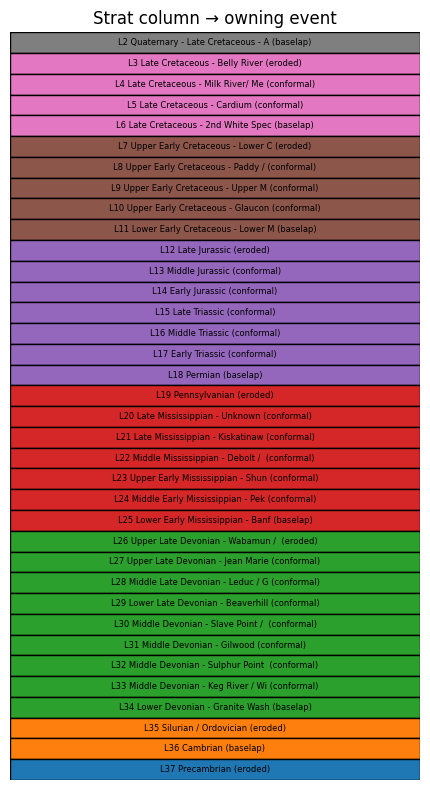

In [4]:
print("derived events (oldest → youngest):")
for ev, meta in zip(M.events, M.field_meta):
    extra = (f"L{','.join(map(str, meta.above_levels))} above unconformity, L{meta.eroded_level} eroded below"
             if meta.is_unconformity else (f"levels={meta.levels}" if meta.levels else ""))
    print(f"  eid={ev.eid:2d}  {meta.kind:11s}  onlap={ev.overprint.defaultDomain:6s}  "
          f"n_iq={meta.n_iq:2d}  {meta.name[:34]:34s}  {extra}")

units = M.strat_units; n = len(units)
ev_of_level = {L: k for k, meta in enumerate(M.field_meta) for L in meta.levels}
cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(4.4, 8))
for i, u in enumerate(units):
    y = n - 1 - i; k = ev_of_level.get(u.level, -1)
    ax.add_patch(plt.Rectangle((0, y), 1, 1, facecolor=cmap(k % 20) if k >= 0 else "lightgray", edgecolor="k"))
    ax.text(0.5, y + 0.5, f"L{u.level} {u.name[:32]} ({u.relation})", ha="center", va="center", fontsize=6)
ax.set_xlim(0, 1); ax.set_ylim(0, n); ax.axis("off"); ax.set_title("Strat column → owning event")
plt.tight_layout(); plt.show()

**GeoModel event graph** (`_repr_svg_`):

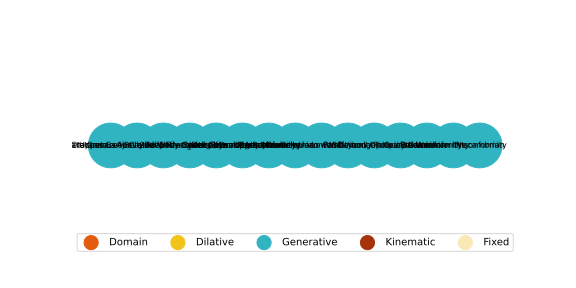

In [5]:
M

## 3. Ordering structure (per field)

There are **no** `eq` traces or `gv` normals — the builder records, per field, the
stratigraphic **ordering** of unit levels (`meta.iq_relations`): for a depositional
package each band sits above the band directly below; for an unconformity the onlapping
(adjacent-younger) package sits above the eroded unit **and every older level**. On the
**coupled** path (§4) these per-field inequalities are *not* optimised directly
(`iq_norm_weight=0`) — the soft-unit carve (`soft_unit_probs`) re-derives the same
youngest-first onlap/truncation ordering as a per-class likelihood, so the relations
below are the structure the coupling encodes globally rather than per pair. Iso-values
do not exist yet — they are **learned** during the joint fit (§4).

In [6]:
# exact per-field constraints recorded at build time (meta.iq_relations: list of
# (above, below_level, '>') where `above` is one level, or a tuple of levels for the
# pooled above side of an unconformity). Each says "<above> points sit above <below> points".
def lab(a):  # an above side is a single level or a pooled tuple of levels
    return "+".join(f"L{x}" for x in a) if isinstance(a, tuple) else f"L{a}"
print("per-field iq constraints  (above  >  below) :")
for ev, meta in zip(M.events, M.field_meta):
    if not meta.iq_relations:
        print(f"  {meta.name[:34]:34s} [{meta.kind}] : (no constraints)")
        continue
    by_above = {}   # above (level or tuple) -> [below_levels]
    for a, b, _ in meta.iq_relations:
        by_above.setdefault(a, []).append(b)
    print(f"  {meta.name[:34]:34s} [{meta.kind}]  ({meta.n_iq} pairs)")
    for a in by_above:
        bs = sorted(by_above[a])
        rng_s = f"L{bs[0]}..L{bs[-1]}" if len(bs) > 2 else ",".join(f"L{b}" for b in bs)
        print(f"      {lab(a)}  >  {rng_s}")

per-field iq constraints  (above  >  below) :
  Precambrian                        [region-only] : (no constraints)
  Precambrian Unconformity           [erosional]  (1 pairs)
      L35+L36  >  L37
  Cambrian                           [depositional]  (1 pairs)
      L35  >  L36
  Silurian / Ordovician Unconformity [erosional]  (3 pairs)
      L26+L27+L28+L29+L30+L31+L32+L33+L34  >  L35..L37
  Lower Devonian - Granite Wash      [depositional]  (8 pairs)
      L26  >  L27
      L27  >  L28
      L28  >  L29
      L29  >  L30
      L30  >  L31
      L31  >  L32
      L32  >  L33
      L33  >  L34
  Upper Late Devonian - Wabamun / To [erosional]  (12 pairs)
      L19+L20+L21+L22+L23+L24+L25  >  L26..L37
  Lower Early Mississippian - Banff  [depositional]  (6 pairs)
      L19  >  L20
      L20  >  L21
      L21  >  L22
      L22  >  L23
      L23  >  L24
      L24  >  L25
  Pennsylvanian Unconformity         [erosional]  (19 pairs)
      L12+L13+L14+L15+L16+L17+L18  >  L19..L37
  Permian   

## 4. Joint fit — soft-unit / NLL coupling

`attach_unit_loss(M)` builds a `UnitLoss` that couples **all** scalar fields
plus shared, **learnable** iso-values in one cross-entropy against the true unit levels
(SOFTUNIT_SPEC §2–§5). It is passed to `M.fit(custom_loss=[uloss])`, so the whole stack
trains jointly from scratch:

* each epoch it samples `POINTS_PER_LEVEL` balanced points per level, evaluates the field
  stack via `ev.predict(combine=False, transform=True)` (deformation-correct; `M.predict`
  untouched), and **carves** an `(N, C)` per-class simplex (`soft_unit_probs`) — a per-class
  re-derivation of curlew's own onlap/truncation combine;
* the loss is `NLL(log carve, true levels)`; every unit point carries a two-sided,
  always-active likelihood (unlike a hinge, which goes flat once satisfied);
* iso-values are learnable Parameters on the loss with a per-package **monotone reparam**
  (`θ_j = θ_0 − cumsum(softplus(φ))`), so a package's contacts cannot cross — surfaces are
  **learned**, not estimated (`estimate_isosurfaces` is NOT used here);
* the no-overturn prior is kept; `iq_norm_weight` is set to 0 (the CE supersedes it).

After fitting, `uloss.write_isosurfaces(M)` pushes the learned iso-values into the ordinary
`addIsosurface(value=...)` (oldest-first, so ascending `lithoID` = younger) so `M.predict`
reproduces the model. Below the loss curve we confirm every unit level is represented in
the balanced pools.

coupling: 36 level-classes | 19 iso parameter groups | tau=0.05 (s=20) | overturn=6.0


Training            0/3000 

final loss: 0.8151885187886548
L=0.815 Late Cretaceous - Belly River Unconformity/overturn_loss=0.000 Late Cretaceous - 2nd White Specks / Dunvegan/overturn_loss=0.000 Upper Early Cretaceous - Lower Colorado Unconformity/overturn_loss=0.000 Lower Early Cretaceous - Lower Mannville/overturn_loss=0.003 Late Jurassic Unconformity/overturn_loss=0.001 Permian/overturn_loss=0.000 Pennsylvanian Unconformity/overturn_loss=0.001 Lower Early Mississippian - Banff / Lodgepole / Bakken/overturn_loss=0.000 Upper Late Devonian - Wabamun / Torquay Unconformity/overturn_loss=0.000 Lower Devonian - Granite Wash/overturn_loss=0.001 Silurian / Ordovician Unconformity/overturn_loss=0.000 Cambrian/overturn_loss=0.000 Precambrian Unconformity/overturn_loss=0.001 unit/nll_loss=0.807

wrote 35 learned surface iso-values:
  Precambrian Unconformity_unconformity            +0.076
  Cambrian_Cambrian Top                            +0.037
  Silurian / Ordovician Unconformity_unconformity  -0.002
  Lower Devonian 

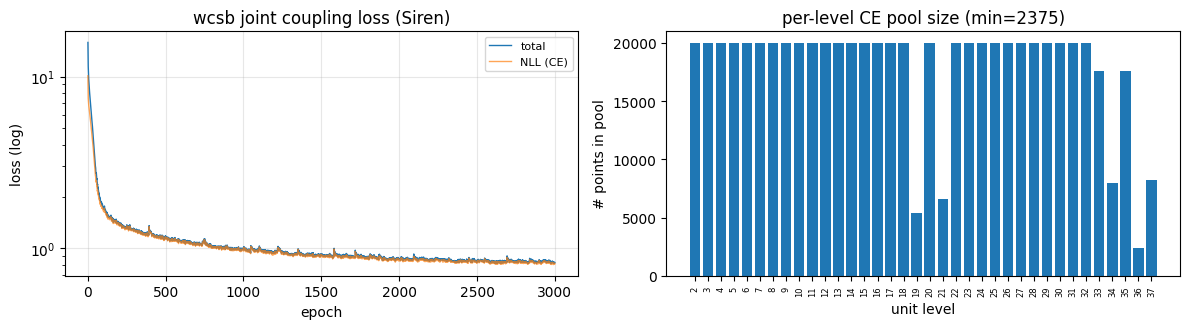

In [7]:
uloss = attach_unit_loss(M, tau=TAU, points_per_level=POINTS_PER_LEVEL,
                         overturn_weight=OVERTURN_WEIGHT)
print(f"coupling: {uloss.n_classes} level-classes | {len(list(uloss._params))} iso parameter groups "
      f"| tau={uloss.tau} (s={1/uloss.tau:.0f}) | overturn={OVERTURN_WEIGHT}")

loss, pebble, history = M.fit(N_EPOCHS, early_stop=None, best=False, history=True, custom_loss=[uloss])
print("final loss:", loss); print(pebble)

isos = uloss.write_isosurfaces(M)   # REQUIRED before any predict (learned iso-values)
print(f"\nwrote {len(isos)} learned surface iso-values:")
for k, v in isos.items():
    print(f"  {k[:48]:48s} {v:+.3f}")

losses = [p.total() for p in history]
nll = [p.losses.get("unit", {}).get("nll_loss", np.nan) for p in history]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(np.arange(1, len(losses) + 1), losses, lw=1, label="total")
ax[0].plot(np.arange(1, len(nll) + 1), nll, lw=1, alpha=0.7, label="NLL (CE)")
ax[0].set_yscale("log"); ax[0].legend(fontsize=8)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss (log)"); ax[0].grid(True, alpha=0.3)
ax[0].set_title(f"wcsb joint coupling loss ({FIELD})")

# per-unit representation in the balanced CE pools (# points per level, capped)
rep = {L: (len(M.level_points.get(L, ())) ) for L in obs.levels("unit")}
levels_sorted = sorted(rep)
ax[1].bar([str(L) for L in levels_sorted], [rep[L] for L in levels_sorted])
ax[1].set_xlabel("unit level"); ax[1].set_ylabel("# points in pool"); ax[1].tick_params(axis="x", labelrotation=90, labelsize=6)
ax[1].set_title(f"per-level CE pool size (min={min(rep.values())})")
plt.tight_layout(); plt.show()

## 5. Per-field scalar fields (inspection)

Each event's field, evaluated **on its own** (`combine=False`) on a vertical section,
with its learned iso-surface(s) contoured. This shows whether each field is
*individually* geologically reasonable (monotone, surface at the right level) —
independently of how the sequential combine assembles them. (Note: a "turn-up" at the
west edge is extrapolation beyond the data plus the real westward basin-margin rise,
not a fitting bug.)

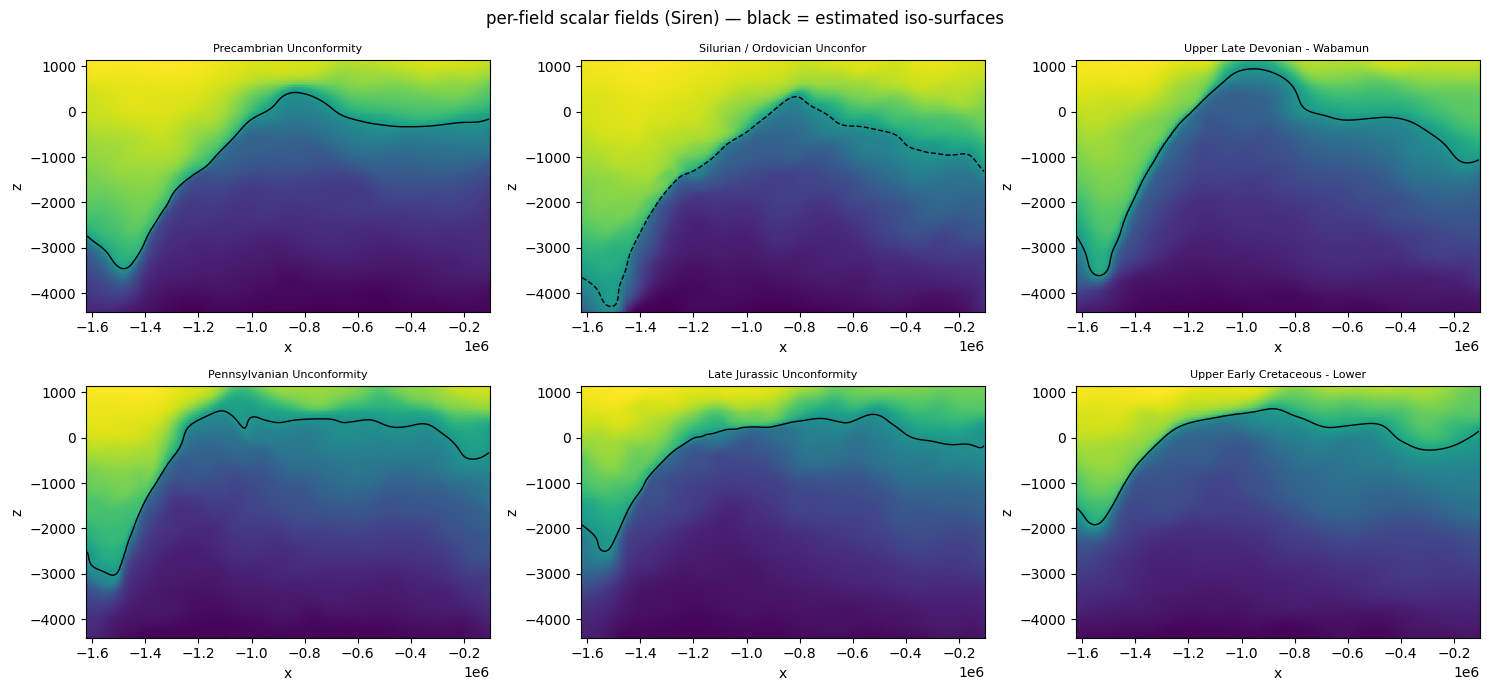

In [8]:
lo, hi = obs.bounds(); lo = np.asarray(lo, float); hi = np.asarray(hi, float)
center = 0.5 * (lo + hi)
nx, nz = 200, 130
xs = np.linspace(lo[0], hi[0], nx); zs = np.linspace(lo[2], hi[2], nz)
XX, ZZ = np.meshgrid(xs, zs); YY = np.full_like(XX, center[1])
SEC = np.stack([XX, YY, ZZ], axis=-1).reshape(-1, 3).astype(float)

# pick a few representative events spanning the column
sel = [ev for ev in M.events if ev.field.C is not None][::2][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes = axes.ravel()
for ax, ev in zip(axes, sel):
    # NB: GeoEvent.predict works in MODEL coords (it does not apply the global→model
    # transform M.T that GeoModel.predict applies). Map the world section into model
    # space first, else the field is evaluated at raw world coordinates (garbage).
    g = ev.predict(T.apply(SEC), combine=False)   # this field only, model coords
    S = g.scalar.reshape(nz, nx)
    pcm = ax.pcolormesh(xs, zs, S, shading="auto", cmap="viridis")
    isov = sorted(ev.getIsovalues().values())
    if isov:
        ax.contour(xs, zs, S, levels=isov, colors="k", linewidths=1.0)
    ax.set_title(ev.name[:30], fontsize=8); ax.set_xlabel("x"); ax.set_ylabel("z")
for ax in axes[len(sel):]: ax.axis("off")
fig.suptitle(f"per-field scalar fields ({FIELD}) — black = estimated iso-surfaces")
plt.tight_layout(); plt.show()

## 6. Combined model — predict & 3D view (WebGL HTML viewer)

`M.predict` assembles all fields via the onlap/truncation combine. The matplotlib
section shows the combined scalar + lithology; the **WebGL HTML viewer** (built below)
shows the lithology volume (coloured by stratigraphic **level**), the **observation
points** (coloured by their true unit so you can judge the fit directly), and the
extracted iso-surfaces — all sharing one unit-visibility mask, palette and X/Y/Z slicer.
Comparing this with §5 shows where the **combine** (not the individual fields) places unit
boundaries.

The predict grid is **high-resolution** (5 km horizontal, 20 m vertical — `predict`
chunks it by `curlew.batchSize`), so the model is large: the viewer is built in **tiled**
mode (a small `.html` plus a binary tile folder served over local HTTP via
`serve_and_open`). The viewer's *Vertical exag.* slider (initialised to ~100×, since the
basin is ~300× wider than it is deep) makes the thin layering visible rather than squashed
onto one plane. Outputs go to `outputs/` (git-ignored); set `OPEN_BROWSER=False` for
headless runs.

grid cells: 28,913,775  shape (303, 347, 275)  (RES_XY=5000 m, RES_Z=20 m)
grid (303, 347, 275) | scalar range -1.2348618309289763 → 1.6081558708378816 | lithologies 36


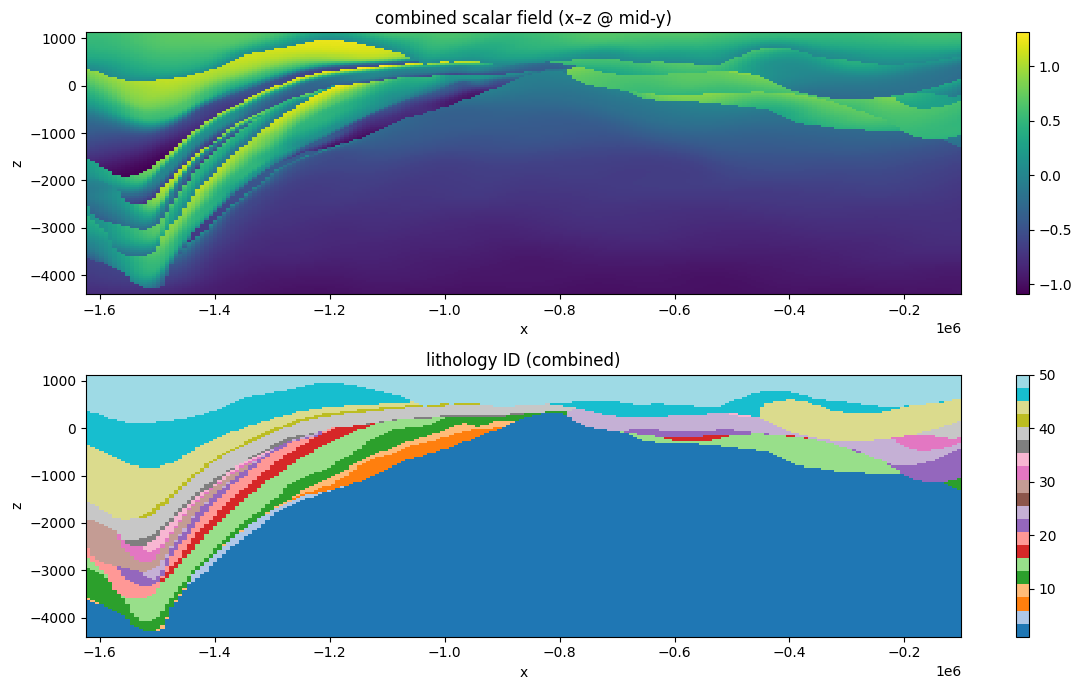

In [9]:
from curlew.geometry import Grid
RES_XY, RES_Z = 5000.0, 20.0
curlew.batchSize = 50000       # predict is chunked by this; lower if you hit GPU OOM, raise for speed
ext = hi - lo
G = Grid(dims=tuple(ext), step=(RES_XY, RES_XY, RES_Z), center=tuple(center))
print(f"grid cells: {int(np.prod(G.shape)):,}  shape {G.shape}  (RES_XY={RES_XY:.0f} m, RES_Z={RES_Z:.0f} m)")
geode = M.predict(G)
print("grid", geode.grid.shape, "| scalar range", float(np.nanmin(geode.scalar)), "→", float(np.nanmax(geode.scalar)),
      "| lithologies", len(np.unique(geode.lithoID)))

sec = M.predict(SEC)
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
pcm = ax[0].pcolormesh(xs, zs, sec.scalar.reshape(nz, nx), shading="auto", cmap="viridis")
fig.colorbar(pcm, ax=ax[0]); ax[0].set_title("combined scalar field (x–z @ mid-y)")
pcm2 = ax[1].pcolormesh(xs, zs, sec.lithoID.reshape(nz, nx), shading="auto", cmap="tab20")
fig.colorbar(pcm2, ax=ax[1]); ax[1].set_title("lithology ID (combined)")
for a in ax: a.set_xlabel("x"); a.set_ylabel("z")
plt.tight_layout(); plt.show()

In [ ]:
from pathlib import Path
from curlew.visualise.html_viewer import write_geomodel_viewer, serve_and_open

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

html = write_geomodel_viewer(
    OUT / "wcsb_viewer.html", M, geode, G,
    obs=obs, color_by="level", mode="tiled", max_points=200000,
    title=f"wcsb ({FIELD})", initial_z_exaggeration=100,
)
print("wrote", html)
serve_and_open(html)

Wrote outputs\wcsb_viewer.html  (+ wcsb_viewer_data/  677.97 MB)
wrote outputs\wcsb_viewer.html
Serving D:\Development\curlew\examples\wcsb\outputs
  -> http://127.0.0.1:49812/wcsb_viewer.html
  (call .shutdown() on the returned server to stop it)


127.0.0.1 - - [20/Jun/2026 18:18:45] "GET /wcsb_viewer.html HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/manifest.json HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] code 404, message File not found
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/grid/xvec.f32 HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/grid/yvec.f32 HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/grid/categories.u8 HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/grid/zvec.f32 HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/grid_mesh/tile_000.bin HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/grid_mesh/tile_001.bin HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:18:46] "GET /wcsb_viewer_data/grid_mesh/tile_002.bin HTTP/1.1" 200 -
127.0.0.1 - - [20/Jun/2026 18:1

### Export for ParaView

Write the predicted volume to a VTK file for detailed inspection (`curlew.io.saveVTK`;
`.vti` since the grid is axis-aligned — use `.vts` for rotated grids). Two unit arrays
are written:

- **`level`** — the predicted unit's stratigraphic level, *the same convention as the
  observation data* (ascending = older; basement = max level; `-1` where the predicted
  lithology is not a unit). This is the array to colour by / compare against the data.
- **`lithoID`** — curlew's internal lithology id (ascending = younger; ids are assigned
  oldest→youngest with gaps for surface-only events). The id→name legend is embedded as
  the `lithoID_legend` field-data array (Spreadsheet view → Field Data) and printed below.

Note that the categorical palettes (here in ParaView, or in the HTML viewer's *Stratigraphy*
/ *High contrast* options) deliberately cycle/shuffle hues so thin adjacent bands stay
distinguishable — apparent out-of-sequence colours are **not** evidence of out-of-sequence
units; check the `level` array here (or the HTML viewer's per-unit legend) instead.

In [11]:
from curlew.io import saveVTK
VTK_PATH = "wcsb_prediction.vti"

# stratigraphic level per voxel (the data's own convention: ascending = older)
lut = np.full(max(M.llookup.values()) + 1, -1, dtype=np.int32)
for L, key in M.level_litho.items():
    lut[M.llookup[key]] = L
saveVTK(VTK_PATH, geode, extra={"level": lut[geode.lithoID]})
print("wrote", VTK_PATH, f"({np.prod(G.shape):,} cells)")
print("\nlithoID legend (id -> unit / band):")
for i, n in sorted(geode.lithoLookup.items()):
    print(f"  {i:3d}  {n}")

wrote wcsb_prediction.vti (28,913,775 cells)

lithoID legend (id -> unit / band):
   -1  Undefined
    1  Precambrian
    2  Precambrian Unconformity
    3  Precambrian Unconformity_unconformity
    4  Cambrian
    5  Cambrian_Cambrian Top
    6  Silurian / Ordovician Unconformity
    7  Silurian / Ordovician Unconformity_unconformity
    8  Lower Devonian - Granite Wash
    9  Lower Devonian - Granite Wash_Lower Devonian - Granite Wash Top
   10  Lower Devonian - Granite Wash_Middle Devonian - Keg River / Winnipegosis Top
   11  Lower Devonian - Granite Wash_Middle Devonian - Sulphur Point / Pine Point / Zama Top
   12  Lower Devonian - Granite Wash_Middle Devonian - Gilwood Top
   13  Lower Devonian - Granite Wash_Middle Devonian - Slave Point / Souris River Top
   14  Lower Devonian - Granite Wash_Lower Late Devonian - Beaverhill Lake / Swan Hills Top
   15  Lower Devonian - Granite Wash_Middle Late Devonian - Leduc / Grosmont / Duperow Top
   16  Lower Devonian - Granite Wash_Upper

## 7. Checks & diagnostics (SOFTUNIT_SPEC §7)

**Asserted** invariants: the builder structure (event chain, every unit represented),
the **by-construction** per-package contact monotonicity (the monotone reparam), and the
**soft-carve ↔ predict consistency** — the training assembly (argmax of the soft carve,
in level space) agrees with the inference assembly (predict's hard `lithoID → level`),
because both use the *same* learned iso-values and fields. This is the direct test of the
sequential-combine fragility the coupling targets. Field-ordering / iso-placement
diagnostics and the **per-point label accuracy** (band / structure / basement) are
*reported* for inspection.

Expect structure (package) accuracy ~0.9 and band (exact unit) accuracy ~0.7 on the full
markers; the residual is dominated by the deep, densely-packed packages (e.g. the Granite
Wash / Mississippian internals), where many thin bands overlap in scalar space — these are
genuinely hard and are also the weakest levels in the GeoINR reference. Lower `OVERTURN_WEIGHT`
fits the markers slightly better but lets the deep unconstrained region overturn (more column
inversions in `predict`); raise it for a cleaner volume at some cost to marker fit.

In [12]:
metas = M.field_meta
def fvals(ev, pts):
    with torch.no_grad():
        return ev.forward(torch.tensor(np.asarray(pts, float), dtype=curlew.dtype,
                                       device=curlew.device)).detach().cpu().numpy().reshape(-1)

results = {}
# 1. event chain
kinds = [m.kind for m in metas]
results["event_chain"] = bool(kinds[0] == "region-only" and kinds[-1] == "region-only"
                              and sum(m.is_unconformity for m in metas) >= 1
                              and sum(m.kind == "depositional" for m in metas) >= 1)
print(f"1. event chain: {len(metas)} events "
      f"({sum(k=='region-only' for k in kinds)} region-only, {sum(m.is_unconformity for m in metas)} erosional, "
      f"{sum(k=='depositional' for k in kinds)} depositional) -> {results['event_chain']}")

# 2. every unit represented in the balanced CE pools
results["every_unit_represented"] = bool(min(rep.values()) > 0)
print(f"2. every unit in the CE pools: min={min(rep.values())} -> {results['every_unit_represented']}")

# 3. per-package contact monotonicity — BY CONSTRUCTION (monotone reparam, SOFTUNIT_SPEC §5)
mono = True
for meta in metas:
    if meta.kind != "depositional" or len(meta.contacts) < 2: continue
    ev = M[meta.name]
    iv = np.array([ev.getIsovalue(c.name) for c in meta.contacts]); d = np.diff(iv)
    mono &= bool(np.all(d < 0))
results["iso_monotonic"] = bool(mono)
print(f"3. per-package iso monotonicity (by construction) -> {results['iso_monotonic']}")

# 4. soft-carve <-> predict consistency (SOFTUNIT_SPEC §7): argmax(carve, level space)
#    == predict's hard lithoID -> level. Both use the SAME learned isos + fields.
rng = np.random.default_rng(7); cpts, clev = [], []
for L in obs.levels("unit"):
    idx = np.where((~obs.is_interface) & (obs.level == L))[0]
    idx = rng.choice(idx, size=min(300, len(idx)), replace=False)
    cpts.append(obs.coords[idx].astype(float)); clev.append(np.full(len(idx), L))
cpts = np.vstack(cpts); clev = np.concatenate(clev)
Xm = M.T(torch.tensor(cpts, dtype=curlew.dtype, device=curlew.device))
with torch.no_grad():
    cprobs = soft_unit_probs(M, Xm, uloss.resolve_isos(), uloss.tau, uloss.spec)
carve_level = np.array([uloss.spec.class_levels[i] for i in cprobs.argmax(1).cpu().numpy()])
gp = M.predict(cpts)
lut2 = {M.llookup[key]: L for L, key in M.level_litho.items()}  # lithoID -> level
pred_level = np.array([lut2.get(int(i), -1) for i in gp.lithoID])
soft_agree = float((carve_level == pred_level).mean())
# the two assemblies use the same learned isos+fields, so they agree up to the
# soft-sigmoid(τ)-vs-hard-threshold boundary shells (and the erosional shell the carve
# discards) — a high but not unity agreement; >=0.9 is the consistency tolerance.
results["soft_predict_consistent"] = bool(soft_agree >= 0.90)
print(f"4. soft-carve == predict (level space): {soft_agree:.4f} -> {results['soft_predict_consistent']}")

# 5. (report) learned unconformity iso between the adjacent clouds (medians)
between = []
for meta in metas:
    if not meta.is_unconformity: continue
    ev = M[meta.name]
    iso = ev.getIsovalue(meta.iso_name)
    a = np.median(fvals(ev, np.concatenate([M.level_points[L] for L in meta.above_levels
                                            if len(M.level_points.get(L, ())) > 0])))
    b = np.median(fvals(ev, M.level_points[meta.eroded_level]))
    between.append(bool(b < iso < a))
results["iso_between"] = bool(all(between))
print(f"5. each learned unconformity iso between adjacent clouds: {sum(between)}/{len(between)} -> {results['iso_between']}")

print("\n" + "=" * 48)
# assert the builder structure + the coupling's by-construction / consistency invariants;
# report the rest (iso placement is now learned by the CE, not forced between the clouds).
ASSERTED = ("event_chain", "every_unit_represented", "iso_monotonic", "soft_predict_consistent")
for k, v in results.items():
    print(f"  {('PASS' if v else ('FAIL' if k in ASSERTED else 'report')):6s} {k}")
assert all(results[k] for k in ASSERTED), "An asserted invariant failed."
print("=" * 48)

1. event chain: 15 events (2 region-only, 7 erosional, 6 depositional) -> True
2. every unit in the CE pools: min=2375 -> True
3. per-package iso monotonicity (by construction) -> True
4. soft-carve == predict (level space): 0.9448 -> True
5. each learned unconformity iso between adjacent clouds: 7/7 -> True

  PASS   event_chain
  PASS   every_unit_represented
  PASS   iso_monotonic
  PASS   soft_predict_consistent
  PASS   iso_between


In [13]:
# --- reported per-point accuracy (SOFTUNIT_SPEC §7 targets: band > 0.61, basement > 0.50) ---
rng = np.random.default_rng(3); pts, lev = [], []
for L in obs.levels("unit"):
    idx = np.where((~obs.is_interface) & (obs.level == L))[0]
    idx = rng.choice(idx, size=min(400, len(idx)), replace=False)
    pts.append(obs.coords[idx].astype(float)); lev.append(np.full(len(idx), L))
pts = np.vstack(pts); lev = np.concatenate(lev); g = M.predict(pts)
litho = np.array([g.lithoLookup.get(int(i), "?") for i in g.lithoID])
struct = np.array([g.structureLookup.get(int(s), "?") for s in g.structureID])
lev_struct = {L: m.name for m in metas for L in m.levels}
lit_ok = np.array([litho[k] == M.level_litho[int(lev[k])] for k in range(len(lev))])
str_ok = np.array([struct[k] == lev_struct[int(lev[k])] for k in range(len(lev))])
base_level = max(obs.levels("unit"))
print(f"band accuracy           : {lit_ok.mean():.3f}   (target > 0.61)")
print(f"structure (package) acc : {str_ok.mean():.3f}")
print(f"basement (L{base_level}) accuracy : {lit_ok[lev == base_level].mean():.3f}   (target > 0.50)")
print("\nper-level structure accuracy (for inspection):")
for L in obs.levels("unit"):
    m = lev == L
    print(f"  L{L:2d} {M.strat_units[[u.level for u in M.strat_units].index(L)].name[:30]:30s} "
          f"struct={str_ok[m].mean():.2f} band={lit_ok[m].mean():.2f}")

band accuracy           : 0.730   (target > 0.61)
structure (package) acc : 0.920
basement (L37) accuracy : 0.578   (target > 0.50)

per-level structure accuracy (for inspection):
  L 2 Quaternary - Late Cretaceous - struct=0.97 band=0.97
  L 3 Late Cretaceous - Belly River  struct=0.99 band=0.95
  L 4 Late Cretaceous - Milk River/  struct=1.00 band=0.95
  L 5 Late Cretaceous - Cardium      struct=1.00 band=0.98
  L 6 Late Cretaceous - 2nd White Sp struct=0.98 band=0.94
  L 7 Upper Early Cretaceous - Lower struct=0.97 band=0.94
  L 8 Upper Early Cretaceous - Paddy struct=0.99 band=0.90
  L 9 Upper Early Cretaceous - Upper struct=0.95 band=0.83
  L10 Upper Early Cretaceous - Glauc struct=0.91 band=0.75
  L11 Lower Early Cretaceous - Lower struct=0.67 band=0.43
  L12 Late Jurassic                  struct=0.94 band=0.72
  L13 Middle Jurassic                struct=0.96 band=0.72
  L14 Early Jurassic                 struct=0.96 band=0.74
  L15 Late Triassic                  struct=0.92 band